# Step 1 import API

In [1]:
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# Step 2 choose your stock

In [2]:

## Import the stock data
TICKERS = ['AAPL', 'MSFT', 'TSLA', 'AMZN', 'BLK']

START_DATE = '2005-01-01'
END_DATE   = '2025-01-01'

## Loading the historical data 
df: pd.DataFrame = YahooDownloader(
                      start_date = START_DATE,
                      end_date = END_DATE,
                      ticker_list = TICKERS

                     ).fetch_data()

print(f"Raw data shape : {df.shape}")
print(df.head())



YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (23784, 8)
Raw data shape : (23784, 8)
Price        date      close       high        low       open      volume  \
0      2005-01-03   0.947307   0.974548   0.936979   0.969609   691992000   
1      2005-01-03   2.226000   2.272000   2.210500   2.247500   208930000   
2      2005-01-03  46.149006  47.105115  46.142915  46.898061       25900   
3      2005-01-03  18.338739  18.482762  18.277016  18.379888    65002900   
4      2005-01-04   0.957036   0.979936   0.942517   0.954790  1096810400   

Price   tic  day  
0      AAPL    0  
1      AMZN    0  
2       BLK    0  
3      MSFT    0  
4      AAPL    1  


### Note

- fetch_data () : Findata transformer to the pandas data.

# Step 3 Build The Normalzied Plt

tic               AAPL        AMZN          BLK        MSFT        TSLA
date                                                                   
2005-01-03    0.947307    2.226000    46.149006   18.338739         NaN
2005-01-04    0.957036    2.107000    46.008934   18.407318         NaN
2005-01-05    0.965418    2.088500    45.582680   18.366175         NaN
2005-01-06    0.966166    2.052500    48.718948   18.345592         NaN
2005-01-07    1.036514    2.116000    47.708023   18.290735         NaN
...                ...         ...          ...         ...         ...
2024-12-24  256.560822  229.050003  1027.918823  434.179321  462.279999
2024-12-26  257.375549  227.050003  1027.383057  432.973694  454.130005
2024-12-27  253.967377  223.750000  1017.540710  425.482513  431.660004
2024-12-30  250.598892  221.300003  1001.218018  419.849365  417.410004
2024-12-31  248.830200  219.389999   998.957214  416.558411  403.839996

[5033 rows x 5 columns]


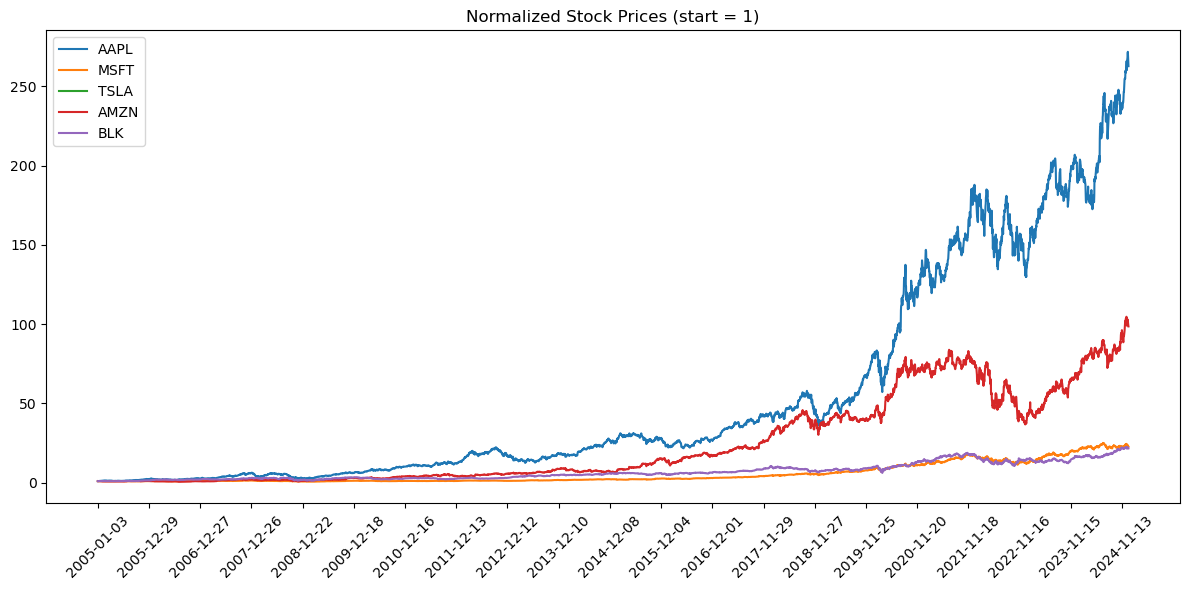

In [3]:
## The data preprocessing

price_df : pd.DataFrame = df.pivot(index='date', columns='tic', values='close')
# This way is transsformer the pivot table to the normal table, and the index is the date, the columns is the tic, and the values is the close price.

price_df = price_df.sort_index()

print(price_df)
## Normalized price data
normalized_price_df = price_df / price_df.iloc[0]

# Draw the normalized price data
plt.figure(figsize=(12, 6))

for tic in TICKERS:
    plt.plot(normalized_price_df.index, normalized_price_df[tic], label=tic)

plt.legend()
plt.title('Normalized Stock Prices (start = 1)')

# The data x fillter (only used the 250 days data)
xticks_idx = range(0, len(normalized_price_df.index), 250)
xticks_labels = [normalized_price_df.index[i] for i in xticks_idx]
plt.xticks(xticks_idx, xticks_labels, rotation=45)
plt.tight_layout()
plt.show()

## Note

- df.pivot : 
    - row: date </br> 
    - cloumn : stock symbol
    - cell  : the close price

## easy weight

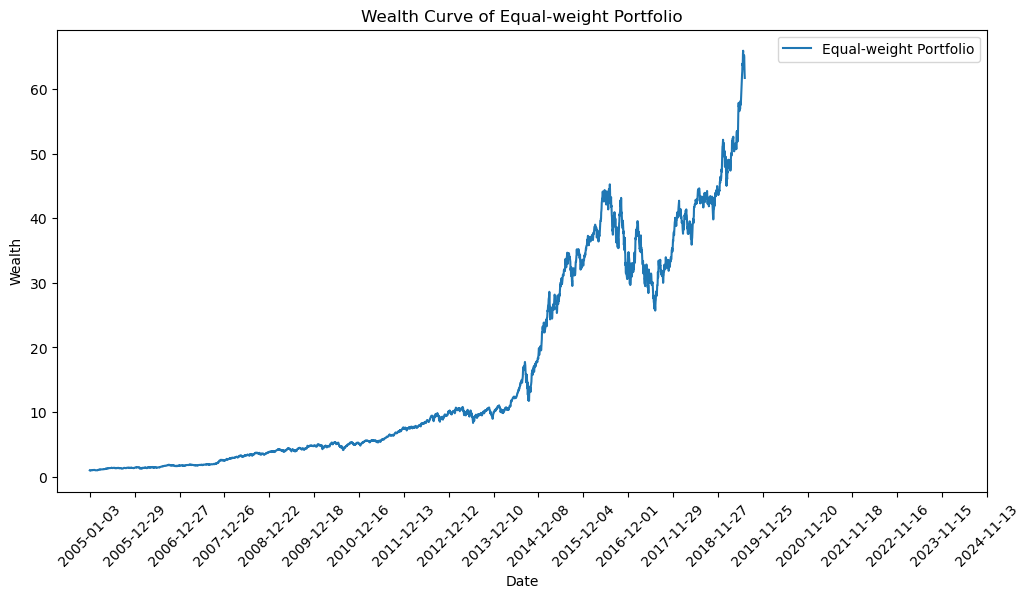

In [4]:
# The equal-weight portfolio, which means the weight of each stock is the same.
# forexample , the  1/5 = 0.25,  I handle the 25% stock in APPL
weight = [1.0 / len(TICKERS)] * len(TICKERS)

# The investment return in day.

returns_df = price_df.pct_change().dropna()
# dropna() is drop out nan value
potfolio_ret: pd.Series = (returns_df * weight).sum(axis=1)
# is array


# The wealth curve is from 1 begin upper
wealth_curve = (1 + potfolio_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(wealth_curve.index, wealth_curve, label="Equal-weight Portfolio")
plt.title('Wealth Curve of Equal-weight Portfolio')

xticks_idx = range(0, len(normalized_price_df.index), 250)
xticks_labels = [normalized_price_df.index[i] for i in xticks_idx]


plt.xticks(xticks_idx, xticks_labels, rotation=45)
plt.xlabel('Date')
plt.ylabel('Wealth')
plt.legend()
plt.show()


## Note
- pct_change() : z - std normalized 
- cumprod() : continue muplipe 

# Step 4 env/mdp transmmistion

In [5]:
import numpy as np
from abc import ABC, abstractmethod
from typing import Tuple , Any

### 4.1 define the protection

In [6]:
class BaseEnv(ABC):
    @abstractmethod
    def reset(self) -> np.ndarray:
        ''' Reset env and return initial state'''
        pass

    @abstractmethod
    def step(self, action: Any) -> Tuple[np.ndarray, float, bool, dict]:
        ''' For agent used
        Args:
            action: action from agent
        
        Returns:
            state: next state after action
            reward: reward after action
            done: whether the episode is done
            info: additional information
        '''
        pass

### note

- if the child fuction didn't implemtion that, It's will apper error.

# Step 4.2 Data sturct management

In [7]:
from dataclasses import dataclass
from typing import List

In [8]:
@dataclass
class PortfolioEnvConfig:

    ''' data structure '''
    tickers: List[str]
    init_wealth: float = 1.0
    wealth_norm_factor: float = 100.0 
    # the cost factor

# Stpe 4.3  Builde the case env

In [9]:
class SimplePortfolioEnv(BaseEnv):
    def __init__(self,price_df: pd.DataFrame, config: PortfolioEnvConfig):
        
        ''' The bondery condition check '''
        missing_tickers: set[str] = set(config.tickers) - set(price_df.columns)
        if missing_tickers :
            raise ValueError(f"Missing tickers in price_df: {missing_tickers}")

        ''' Data structure '''
        self.price_df = price_df[config.tickers].sort_index()            # the stock all info
        self.config = config
        self.tickers = list(config.tickers)
        self.num_assets = len(self.tickers) # handle the number of stock 
        self.init_wealth = config.init_wealth


        ''' Env state '''
        self.returns = self.price_df.pct_change().fillna(0.0) # the stock return
        self.max_step = len(self.price_df) - 1 # the max step of env

        ''' Basic storage '''
        self.equal_w = np.array([1.0 / self.num_assets] * self.num_assets, dtype=float)
        
        self.current_step:int = 0
        self.current_wealth: float = self.init_wealth
    
    def reset(self) -> np.ndarray:
        self.current_step = 0
        self.current_wealth = self.init_wealth
        first_price = self.price_df.iloc[self.current_step][self.tickers].values.astype(float)
        
        return first_price
    
    def step(self, action: np.ndarray = None):
        if self.current_step >= self.max_step:
            raise ValueError("Episode has ended. Please reset the environment.")
            # raise == assert
        weight: np.ndarray = self.equal_w

        ret_vec: np.ndarray = self.returns.iloc[self.current_step+1].values.astype(float)
        reward: float = float(np.dot(weight, ret_vec))
        self.current_wealth *= (1.0 + reward)
        self.current_step += 1
        
        next_price = self.price_df.iloc[self.current_step].values.astype(float)
        done = (self.current_step >= self.max_step)
        info = {"current_wealth": self.current_wealth}
        
        return next_price ,reward, done , info 

In [10]:
config = PortfolioEnvConfig(tickers= TICKERS, init_wealth= 1.0)
env = SimplePortfolioEnv(price_df= price_df, config= config)

state = env.reset() # init state
wealth_list = [env.current_wealth] # record the wealth curve
reward_list = []

done = False

while (not done):
    next_state, reward, done, info = env.step()
    wealth_list.append(info["current_wealth"])
    reward_list.append(reward)
    
    state = next_state


wealth_env = pd.Series(wealth_list, index=price_df.index)
# the data aligne

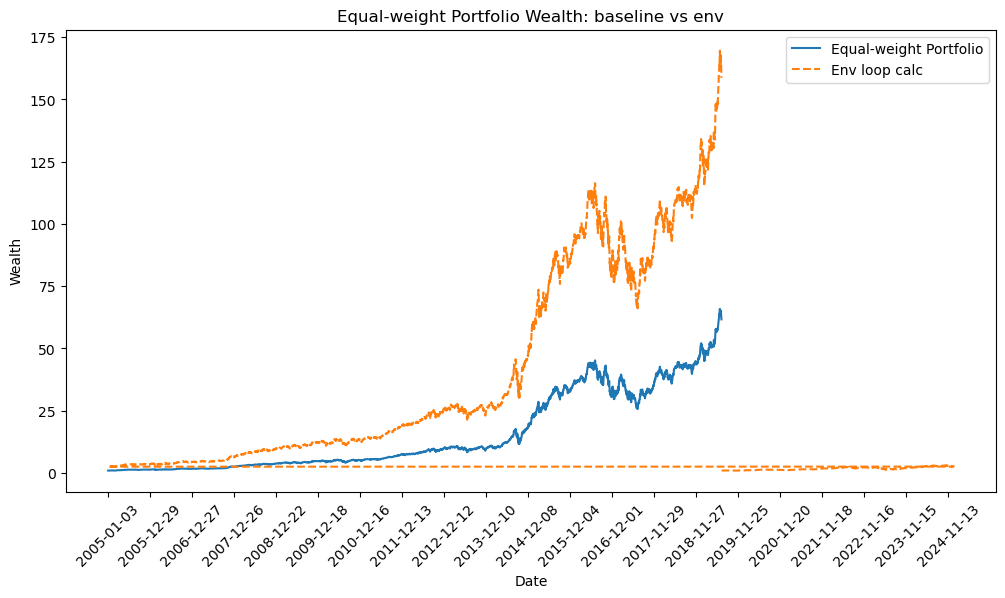

In [11]:
plt.figure(figsize=(12, 6))

# baseline
plt.plot(wealth_curve.index, 
         wealth_curve, 
         label="Equal-weight Portfolio")

# the simple agent
plt.plot(wealth_env.index, 
         wealth_env.values,
         label="Env loop calc", 
         linestyle="--")

xticks_idx = range(0, len(normalized_price_df.index), 250)
xticks_labels = [normalized_price_df.index[i] for i in xticks_idx]
plt.xticks(xticks_idx, xticks_labels, rotation=45)

plt.title("Equal-weight Portfolio Wealth: baseline vs env")
plt.xlabel('Date')
plt.ylabel('Wealth')

plt.legend()
plt.show()

In [12]:
print("Baseline returns_df columns:", returns_df.columns.tolist())
print("Env price_df columns:", env.price_df.columns.tolist())

print("First 5 baseline portfolio_ret:")
print(potfolio_ret.head())

print("First 5 env reward:")
print(reward_list[:5])

Baseline returns_df columns: ['AAPL', 'AMZN', 'BLK', 'MSFT', 'TSLA']
Env price_df columns: ['AAPL', 'MSFT', 'TSLA', 'AMZN', 'BLK']
First 5 baseline portfolio_ret:
date
2010-06-30   -0.008524
2010-07-01   -0.018000
2010-07-02   -0.025186
2010-07-06   -0.021016
2010-07-07    0.018886
dtype: float64
First 5 env reward:
[-0.008496911422171282, -0.0023044242503302173, 0.01024432267196711, 0.016001723177635464, 0.0025920496348559975]


- xticks_idx:
    - The x axis postion ,like 0 ,250 .. the time point

- label:
    - "2005-01-03"

# The DDPG agent

# Stpe 1 build the trainning env

In [13]:
import gymnasium as gym # The RL env
import torch 
from gymnasium import spaces # The action space and observation space
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise

In [ ]:
class GymPortfolioEnv(gym.Env,BaseEnv):
    ''' for DDPG '''
    metadata = {"render.modes": ["human"]}

    def __init__(self, price_df: pd.DataFrame, config: PortfolioEnvConfig):
        super().__init__()
        self.env = SimplePortfolioEnv(price_df, config)

        ''' Bondery condition check '''
        missing_tickers: set[str] = set(config.tickers) - set(price_df.columns)
        # The set chenk , used the minous
        if missing_tickers:
            raise ValueError(f"Missing tickers in price_df: {missing_tickers}")
        

        ''' The env config '''
        self.core_env = SimplePortfolioEnv(price_df =price_df, config =config)
        self.config = config
        self.num_assets = self.core_env.num_assets # decision the observation length and action length

        ''' Gym env space '''
        observation_dim = self.num_assets + 1 # the every day fundtaiton price + wealth 

        self.observation_space = spaces.Box(
            low= -np.inf, 
            high=np.inf, 
            shape=(observation_dim,), 
            dtype=np.float32)
        

        
        self.action_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(self.num_assets,),
            dtype=np.float32)


    ''' fucntion '''    
    def action_to_weight(self, action: np.ndarray) -> np.ndarray:
        ''' Convert action to weight '''

        a = np.array(action, dtype= np.float32)
        a = np.maximum(a, 0.0) # the action must be positive 確保不再次做空

        if a.sum() == 0:
            return np.ones(self.num_assets, dtype=float) / self.num_assets
    
        return a / a.sum() # the action must be sum to 1.0 （也就是比例強制弄到 = 1)
    

    def reset(self, * , seed: int | None = None, options: dict | None = None) -> np.ndarray:
        
        if seed is not None:
            np.random.seed(seed)

        self.core_env.reset()

        observation = np.zeros(self.num_assets + 1, dtype=np.float32)
        observation[-1] = np.float32(self.core_env.current_wealth /
                                     self.config.wealth_norm_factor)
        info = {}
        return observation ,info


    def step(self, action: np.ndarray) -> Tuple[np.ndarray, float, bool, dict]:
        
        ''' step 1 action is weight '''
        weight = self.action_to_weight(action)

        ''' step 2 the weight update '''
        ret_vec = self.core_env.returns.iloc[self.core_env.current_step + 1].values.astype(float)
        port_ret = float(np.dot(weight, ret_vec))

        self.core_env.current_wealth *= (1.0 + port_ret)
        # the countiune muplication
        self.core_env.current_step += 1

        ''' step 3 the observation '''
        next_ret_vec = ret_vec.astype(np.float32)
        norm_wealth = np.float32(self.core_env.current_wealth / self.config.wealth_norm_factor)
        # This way is wealth normalization
        observation = np.concatenate((next_ret_vec, [norm_wealth])).astype(np.float32)

        ''' step 4 the reward ''' 
        reward = port_ret
        terminated = (self.core_env.current_step >= self.core_env.max_step)
        truncated = False
        info = {"wealth": self.core_env.current_wealth, "portfolio_return": port_ret}

        return observation, reward, terminated, truncated, info

## Note
---
- space.Box(low = 0.0 , high = 1.0 , shape=(3,))
    - 這邊表示 每一個觀測的視窗長度會是3 , 並且每一維的數值都是在[0,1] 之間

- low= -np.inf, 
- high=np.inf, 
    - 代表這個觀測空監視有被 z score 等正規化方式給正規化，因此上下限才沒有限制

- observation = np.concatenate((next_ret_vec, [norm_wealth])).astype(np.float32)
    - 語法等價於 arrays = (next_ret_vec, np.array([norm_wealth])) # 這邊是使用 tuple
    - concatenate : 進行數列連接，這邊有兩個參數 ， 第一個參數一定要是tuple, 第二個參數則是要 指令拼接方向
        axis = 0 縱向 axis = 1 橫向

        


### review

In [17]:
obs = env.reset()
print("obs shape:", obs.shape)
print("first obs:", obs)


obs shape: (5,)
first obs: [ 0.94730693 18.3387394          nan  2.22600007 46.14900589]


In [ ]:
device = torch.device("cpu")

n_actions = env.action_space.shape[-1]

action_noise = NormalActionNoise(
    mean=np.zeros(n_actions),
    sigma=0.1 * np.ones(n_actions) # The normalized disturbution noise,
                                   # 在每次下單的權重隨機偏移0.1 以免陷入局部最優
                                   # 基本上這個概念就跟學習率一樣，讓模型在學習過程中有一定的隨機性，避免陷入局部最優解
)

model = DDPG(
    "MlpPolicy",
    env,
    action_noise=action_noise,
    verbose=1, # log level
    learning_rate=1e-3, # 學習率
    batch_size=64, # 從歷史池中抽多少樣本出來學
    gamma=0.99, # 折扣因子，決定了模型對未來獎勵的重視程度，越接近1表示越重視未來獎勵
    tau=0.005, # 這個就是在計算從每次從online network 要轉多少權重到 target network 的參數
    train_freq=(1, "step"), # 每走一步 env step  就在 replay buffer 抽一個 batch 來梯度更新
    gradient_steps=1, # 這邊就進行一次梯度更新 ， 簡單來說就是一個資料學一次 （一次梯度更新）
    device=device,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
action = env.action_space.sample()
# 這邊就是用來產生一個初始化的action , 並且給每個股票一個隨機持股比例
# 例如 AAPL = 0.2 , MSFT = 0.3 , TSLA = 0.1 , AMZN = 0.4 , BLK = 0.0

next_obs, reward, terminated, truncated, info = env.step(action)

print("next_obs shape:", next_obs.shape, "reward:", reward, "terminated:", terminated)

next_obs shape: (6,) reward: -0.017522805858427463 terminated: False


In [ ]:
model.learn(total_timesteps=10_000)

## THe DDPG History replay
- 回放訓練好的完整軌跡

In [ ]:
obs, info = env.reset()

done = False  # Gymnasium 用 terminated + truncated，我們用一個合併的 flag 方便寫 loop
wealth_traj = [env.core_env.current_wealth]
# 紀錄財富的變化，這邊使用 list 加入對應的歷史軌跡

while not done:

    action, _ = model.predict(obs, deterministic=True)
    # deterministic 是否要開啟隨機探索 是 = False 代表當前策略可調 否 = True 代表當前策略不可調 就是當前策略的 action
    # 可以讓dqn 試不同組合
    obs, reward, terminated, truncated, info = env.step(action) # 將動作投到市場進行交互
    
    wealth_traj.append(info["wealth"])

    done = terminated or truncated